In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PyIF import te_compute as te
from scipy import signal

/Users/hades/Desktop/Bruchas Lab/Encoder_Decoder/venv/lib/python3.10/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [2]:
source = "/Users/hades/Desktop/Bruchas Lab/Encoder_Decoder/DJM_binary_classification/Relate_Terminal_to_NAc/signal_data"
files = sorted([f for f in os.listdir(source) if f.endswith(".npy")])
full_paths = [os.path.join(source, f) for f in files]
np_arrs = [np.load(f) for f in full_paths]

nac1 = np_arrs[0]
nac2 = np_arrs[1]
nac3 = np_arrs[2]
nac4 = np_arrs[3]
nac5 = np_arrs[4]
terminal = np_arrs[5]

clusters = [
    nac1,
    nac2,
    nac3,
    nac4,
    nac5
]

In [3]:
def generate_surrogate(series):
    return np.random.permutation(series)

def bandpass_filter(data, lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    return signal.filtfilt(b, a, data)

In [4]:
sampling_rate = 700/71

filtered_terminal = bandpass_filter(terminal, 0.01, 0.5, sampling_rate, 5)
filtered_clusters = [
    bandpass_filter(nac1, 0.01, 0.5, sampling_rate, 5),
    bandpass_filter(nac2, 0.01, 0.5, sampling_rate, 5),
    bandpass_filter(nac3, 0.01, 0.5, sampling_rate, 5),
    bandpass_filter(nac4, 0.01, 0.5, sampling_rate, 5),
    bandpass_filter(nac5, 0.01, 0.5, sampling_rate, 5)
]

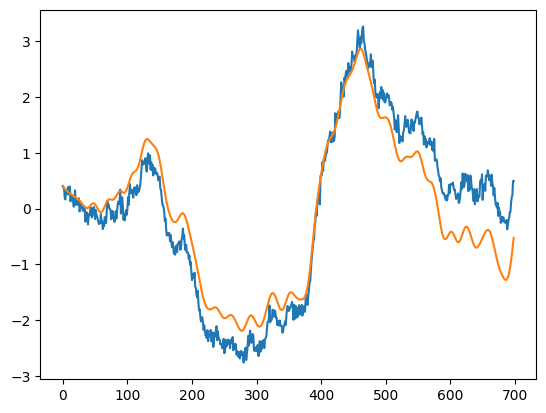

In [20]:
plt.plot(nac5)
plt.plot(filtered_clusters[4])
plt.show()

In [5]:
for i, cluster in enumerate(filtered_clusters, start=1):
    te_res = te.te_compute(filtered_terminal, cluster)

    n_surrogates = 1000
    surrogate_te = np.zeros(n_surrogates)

    for j in range(n_surrogates):
        surrogate_signal = generate_surrogate(cluster)
        surrogate_te[j] = te.te_compute(filtered_terminal, surrogate_signal)
    
    if te_res >= 0:
        p_value = np.sum(surrogate_te >= te_res) / n_surrogates
    else:
        p_value = np.sum(surrogate_te <= te_res) / n_surrogates

    print(f"Cluster {i} -- : TE: {te_res:.4f}, P-value: {p_value:.4f}")

Cluster 1 -- : TE: 0.4998, P-value: 0.0000
Cluster 2 -- : TE: 0.4303, P-value: 0.0000
Cluster 3 -- : TE: 0.1969, P-value: 0.0000
Cluster 4 -- : TE: 0.2609, P-value: 0.0000
Cluster 5 -- : TE: 0.3429, P-value: 0.0000


In [6]:
for i, cluster in enumerate(filtered_clusters, start=1):
    te_res = te.te_compute(cluster, filtered_terminal)
    
    n_surrogates = 1000
    surrogate_te = np.zeros(n_surrogates)

    for j in range(n_surrogates):
        surrogate_signal = generate_surrogate(cluster)
        surrogate_te[j] = te.te_compute(surrogate_signal, filtered_terminal)
    
    if te_res >= 0:
        p_value = np.sum(surrogate_te >= te_res) / n_surrogates
    else:
        p_value = np.sum(surrogate_te <= te_res) / n_surrogates

    print(f"Cluster {i} -- : TE: {te_res:.4f}, P-value: {p_value:.4f}")

Cluster 1 -- : TE: 0.3251, P-value: 0.0000
Cluster 2 -- : TE: 0.0737, P-value: 0.2150
Cluster 3 -- : TE: 0.2708, P-value: 0.0010
Cluster 4 -- : TE: 0.4230, P-value: 0.0000
Cluster 5 -- : TE: 0.4944, P-value: 0.0000
